<a href="https://colab.research.google.com/github/DDanso98/assignment_12/blob/main/Assignment_12_DDanso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 12: Neural Network and Deep Learning Basics | Dominic Danso - September 20, 2026**

*GitHub Repo: https://github.com/DDanso98/assignment_12.git*

**Introduction**

**Objective** Build, train, and evaluate a simple **feedforward neural network** that classifies small colour images of everyday objects, and see what such a network can and cannot do compared with traditional machine learning.

**Dataset** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html): 60,000 colour images of 32 x 32 pixels in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), with 6,000 images per class. The standard split has 50,000 training images and 10,000 test images. It is loaded directly through TensorFlow/Keras.

**Deep learning versus traditional machine learning** Traditional models such as Random Forests and SVMs typically work well on a fixed table of features. A neural network can learn its own intermediate features layer by layer, which is the main idea behind deep learning.

In [2]:
#Import Relevant Libraries
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
keras.utils.set_random_seed(SEED) #Seeds Python, NumPy and TensorFlow together

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Task 1: Dataset Preparation**

`Dataset Choice`

I chose **CIFAR-10** because:
- it contains **everyday objects** (animals and vehicles) photographed in varied poses, lighting, and backgrounds, which makes it a realistic test of image classification;
- it is **small enough to train on an ordinary CPU** in minutes;
- it is **balanced** (the same number of images per class), so plain accuracy is a fair metric;
- it is a standard benchmark built into Keras, so results can be put in context.

`Loading of Data`

`cifar10.load_data()` downloads the dataset the first time it is called and returns the official training and test sets as NumPy arrays. The class names are not included in the data, so they're explicitly listed below.

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Training images:", x_train_full.shape, "dtype:", x_train_full.dtype)
print("Training labels:", y_train_full.shape)
print("Test images:", x_test.shape)
print("Pixel value range:", x_train_full.min(), "to", x_train_full.max())
print("Label values:", np.unique(y_train_full))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1665s 10us/step
Training images: (50000, 32, 32, 3) dtype: uint8
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Pixel value range: 0 to 255
Label values: [0 1 2 3 4 5 6 7 8 9]


- Images have the following shape: 32 pixels high, 32 wide, and 3 colour channels (red, green, blue). There are 50,000 training images and 10,000 test images.
- Pixel values are stored as integers from 0 to 255, so they will need to be rescaled.

`Data Visualization`

To understand the variety within each class, the grid below shows 8 randomly chosen training images per class (one row per class).

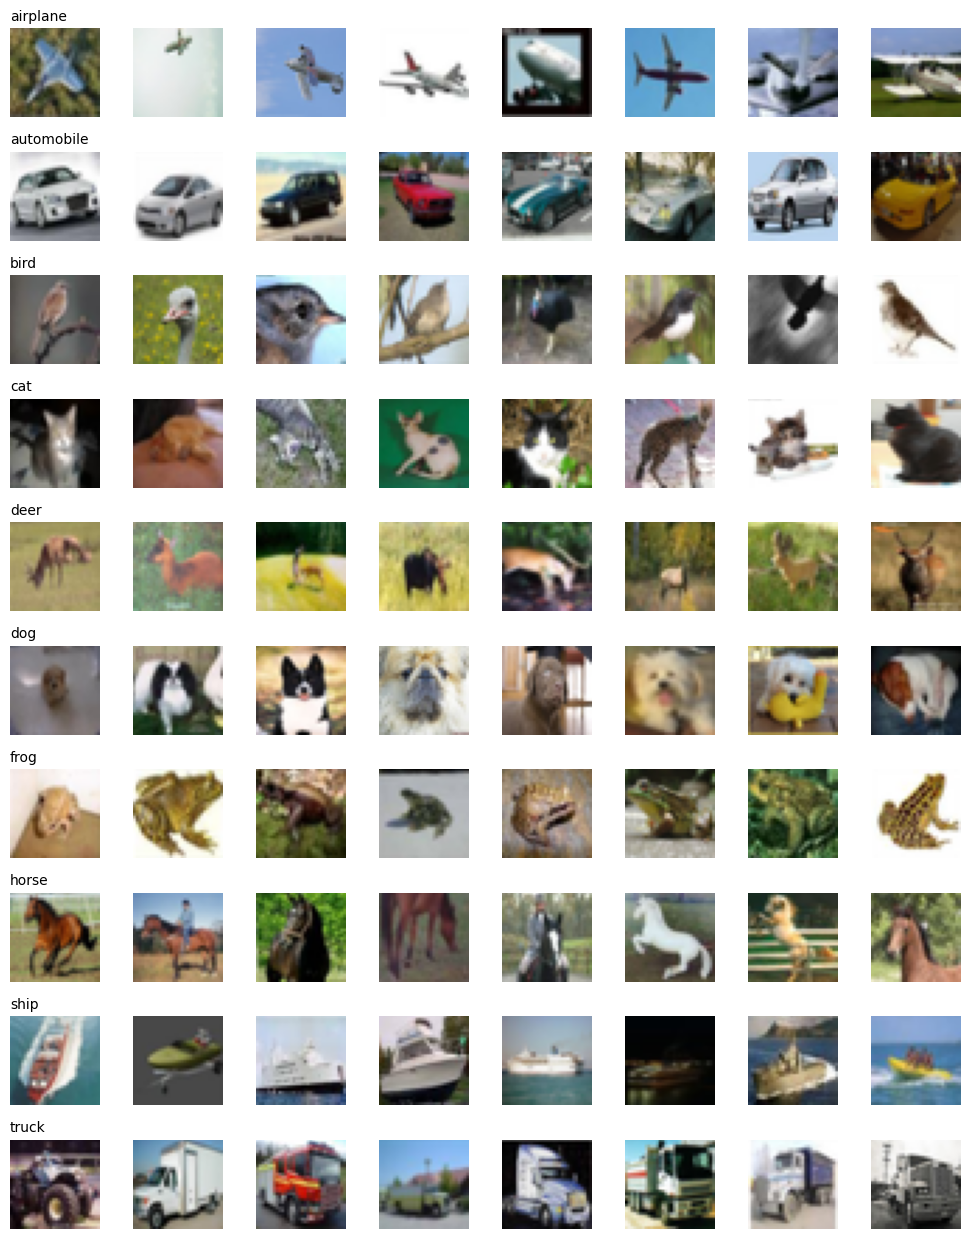

In [6]:
rng = np.random.default_rng(SEED) #Separate random generator so the picks are repeatable

fig, axes = plt.subplots(10, 8, figsize=(10, 12.5))
for label, name in enumerate(class_names):
    class_indices = np.where(y_train_full.flatten() == label)[0]
    chosen = rng.choice(class_indices, size=8, replace=False)
    for col, idx in enumerate(chosen):
        axes[label, col].imshow(x_train_full[idx])
        axes[label, col].axis("off")
        if col == 0:
            axes[label, col].set_title(name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

**Observations**:
- The images are **tiny (32 x 32)**, so fine detail is lost. Even for a person, some images (a camouflaged frog, a deer in shadow) are hard to identify.
- **Appearance varies a lot within a class**: objects differ in pose, size, position in the frame, colour (automobiles come in every colour), viewing angle, and background. The network cannot rely on one fixed "look" per class.
- **Backgrounds carry information.** Airplanes and ships are usually photographed against sky or water, while animals are usually on grass, dirt, or indoor backgrounds. A model can exploit this: a colour-based shortcut that is not the same as recognizing the object.
- **Some classes look alike**: cats and dogs (often close-up faces), automobiles and trucks, and deer and horses. Expect these pairs to be confused more often than unrelated classes.

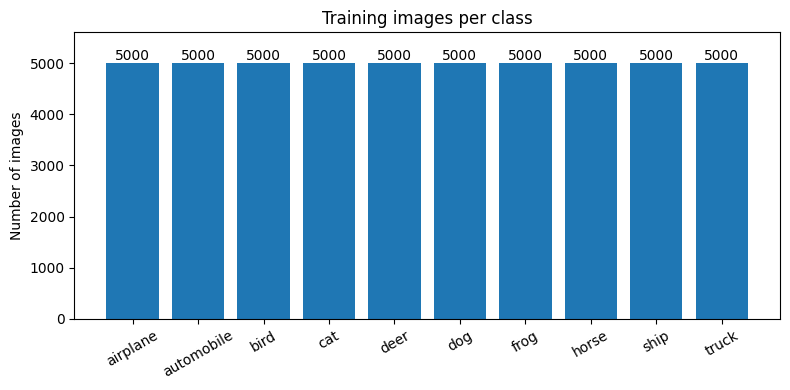

In [7]:
#Training Set: Class Distribution
train_counts = np.bincount(y_train_full.flatten())

plt.figure(figsize=(8, 4))
plt.bar(class_names, train_counts)
plt.title("Training images per class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.ylim(0, 5600)
for i, c in enumerate(train_counts):
    plt.text(i, c + 60, str(c), ha="center")
plt.tight_layout()
plt.show()

**Class balance** Every class has exactly 5,000 training images (and 1,000 test images). Since the classes are perfectly balanced, no class is favoured by the training process, there is no need for class weights.

**Task 2: Image Preprocessing**

`Normalization`

Pixel values are scaled from the 0-255 range to **0-1** by dividing by 255. Small inputs on a common scale make training smoother and faster. The images are also converted from integers to 32-bit floating-point numbers, which is what the network computes with.

`Label Encoding`

The loss function used later, **categorical cross-entropy**, compares the network's 10 output probabilities with a *one-hot* vector: a list of 10 numbers with a 1 in the position of the true class and 0 elsewhere (for example, "cat" = class 3 becomes `[0,0,0,1,0,0,0,0,0,0]`). `to_categorical` converts the integer labels into this form

In [8]:
#Normalize pixel values to the 0-1 range
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(f"Pixel value range after scaling: {x_train_full.min():.1f} to {x_train_full.max():.1f}")

Pixel value range after scaling: 0.0 to 1.0


In [9]:
#Keep integer labels (for scikit-learn metrics) and create one-hot labels (for Keras)
y_train_full_int = y_train_full.flatten()
y_test_int = y_test.flatten()

y_train_full_onehot = to_categorical(y_train_full_int, num_classes=10)
y_test_onehot = to_categorical(y_test_int, num_classes=10)

print("Label 0 as an integer:", y_train_full_int[0], "-> one-hot:", y_train_full_onehot[0])

Label 0 as an integer: 6 -> one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


`Training, Validation, & Test Sets`

The 50,000 training images are split into **45,000 for training** and **5,000 for validation**. The three sets have different jobs:
- **Training set**: the network learns its weights from these images.
- **Validation set**: monitored after every epoch to check whether the network is generalizing to images it is not training on. It is also used to *compare and choose between models* afterwards.
- **Test set** (10,000 images): kept completely untouched until the evaluation. Since it never influences any decision, its score is an honest estimate of performance on new images.

The split is also **stratified**, meaning each class keeps the same proportion in both parts (500 validation images per class)

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full_onehot, test_size=0.1, random_state=SEED, stratify=y_train_full_int)

del x_train_full #To free memory (the split copies above are sufficient moving forward)

print("Training set  :", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set      :", x_test.shape)

Training set  : (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set      : (10000, 32, 32, 3)


`Data Augmentation`

**Data augmentation** creates extra training examples by applying small random changes to the training images. A cat that is shifted slightly, rotated a little, or mirrored is still a cat, so the network is shown more variety than the 45,000 original images contain, which can make it less likely to memorize them. Keras's `ImageDataGenerator` applies these changes on the fly, producing a freshly altered version of each image every epoch:


There is no vertical flip because upside-down animals and vehicles are unrealistic. Augmentation is applied **only to the training images**; validation and test images are never altered, so they measure performance on real, unmodified images.

The cell below shows one cat image and eight random augmented versions of it: each is still the same object (with the same label)

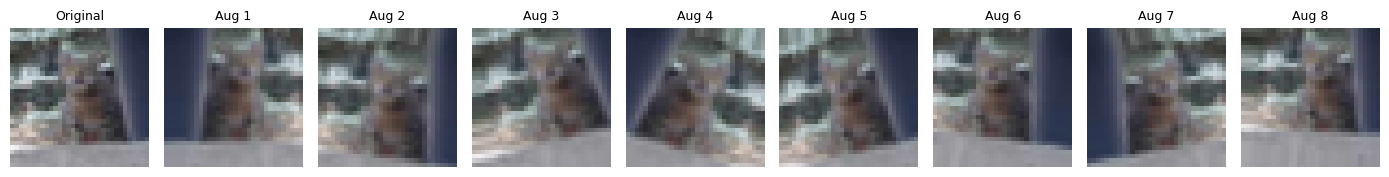

In [11]:
datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True)

#Reveal one cat image from the training set + eight augmented versions of it
cat_index = np.where(np.argmax(y_train, axis=1) == 3)[0][0]
sample_image = x_train[cat_index:cat_index + 1]
augmented_iter = datagen.flow(sample_image, batch_size=1, seed=SEED)

fig, axes = plt.subplots(1, 9, figsize=(14, 2))
axes[0].imshow(sample_image[0])
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")
for i in range(1, 9):
    axes[i].imshow(next(augmented_iter)[0])
    axes[i].set_title(f"Aug {i}", fontsize=9)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

**Task 3: Neural Network Implementation**

`Model Architecture`

The baseline model is a simple feedforward network with **two hidden layers**:

| Layer | Output size | Purpose |
|---|---|---|
| `Flatten` | 3,072 | turns each 32 x 32 x 3 image into one list of 32 x 32 x 3 = 3,072 numbers |
| `Dense(512, relu)` | 512 | first hidden layer: 512 neurons, each looking at every input pixel |
| `Dense(256, relu)` | 256 | second hidden layer: combines the first layer's outputs |
| `Dense(10, softmax)` | 10 | output layer: one probability per class |

Key ideas:
- **Dense (fully connected) layer**: every neuron receives input from every neuron in the previous layer, so a layer with 512 neurons on 3,072 inputs has 3,072 x 512 weights plus 512 bias terms.
- **ReLU activation** (`relu`): outputs `max(0, x)`. Without a non-linear activation, stacking layers would be no more powerful than a single linear layer. ReLU is simple, fast, and avoids the vanishing-gradient problem that affects older activations.
- **Softmax output**: turns the 10 output values into probabilities that are positive and sum to 1. The predicted class is the one with the highest probability.
- **Flatten** is what makes this a *plain feedforward* network for images: it discards the 2-D layout, so the network cannot directly use the fact that neighbouring pixels are related.

The architecture is wrapped in a function, `build_model`. The seed is set inside the function so every model starts from the same random state, which keeps comparisons fair.

In [12]:
#Define Function for Feedforward Network
def build_model(hidden_units):
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Flatten())
    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))
    return model

baseline_model = build_model([512, 256])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

The parameter counts follow directly from the layer sizes:
- First hidden layer: 3,072 x 512 weights + 512 biases = **1,573,376** parameters
- Second hidden layer: 512 x 256 + 256 = **131,328**
- Output layer: 256 x 10 + 10 = **2,570**
- Total: **1,707,274** trainable parameters

Almost all of the parameters (92%) sit in the first layer, because every one of the 3,072 input pixels connects to every one of its 512 neurons. This is a weakness of dense layers on images: the number of parameters grows quickly with image size, yet none of them are specialized to detect local patterns such as edges.

`Compilation`

Before training, the model must be told how to learn:
- **Optimizer - Adam:** Adam is a variant of gradient descent that keeps a running average of past gradients and adapts the step size for each weight individually. It usually works well with little tuning, which is why it is a common default.
- **Loss - categorical cross-entropy:** Measures how far the predicted probabilities are from the one-hot true label. It is small when the network assigns high probability to the correct class and grows sharply when it is confidently wrong. This is the standard loss for multi-class classification with softmax outputs.
- **Metric - accuracy:** The share of images classified correctly. It is reported during training for monitoring but is not used to update the weights (only the loss is).

In [13]:
baseline_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

`Training`

In [14]:
BATCH_SIZE = 64
EPOCHS = 15

start = time.time()
baseline_history = baseline_model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_val, y_val), verbose=2).history
baseline_time = time.time() - start

print(f"\nTraining time: {baseline_time:.0f} seconds")

Epoch 1/15
704/704 - 21s - 31ms/step - accuracy: 0.3203 - loss: 1.8821 - val_accuracy: 0.3370 - val_loss: 1.8114
Epoch 2/15
704/704 - 19s - 27ms/step - accuracy: 0.3971 - loss: 1.6841 - val_accuracy: 0.4106 - val_loss: 1.6408
Epoch 3/15
704/704 - 20s - 28ms/step - accuracy: 0.4306 - loss: 1.5983 - val_accuracy: 0.4236 - val_loss: 1.5985
Epoch 4/15
704/704 - 19s - 27ms/step - accuracy: 0.4529 - loss: 1.5333 - val_accuracy: 0.4276 - val_loss: 1.5937
Epoch 5/15
704/704 - 21s - 30ms/step - accuracy: 0.4678 - loss: 1.4896 - val_accuracy: 0.4524 - val_loss: 1.5495
Epoch 6/15
704/704 - 18s - 26ms/step - accuracy: 0.4820 - loss: 1.4497 - val_accuracy: 0.4598 - val_loss: 1.5294
Epoch 7/15
704/704 - 22s - 31ms/step - accuracy: 0.4940 - loss: 1.4180 - val_accuracy: 0.4514 - val_loss: 1.5256
Epoch 8/15
704/704 - 19s - 28ms/step - accuracy: 0.5031 - loss: 1.3921 - val_accuracy: 0.4596 - val_loss: 1.5170
Epoch 9/15
704/704 - 21s - 30ms/step - accuracy: 0.5104 - loss: 1.3695 - val_accuracy: 0.4496 - 

- A **batch** is the group of images processed before the weights are updated. With 45,000 training images and a batch size of 64, each epoch makes about 704 weight updates. Smaller batches update more often but give noisier gradient estimates.
- An **epoch** is one full pass through the training set. 15 epochs means the network sees every training image 15 times.
- `validation_data` makes Keras evaluate on the 5,000 validation images at the end of every epoch, so we can watch whether the network is learning patterns that carry over to images it is not training on.

`verbose=2` prints one summary line per epoch. The training history is saved so the learning curves can subsequently be plotted.

**Task 4: Model Evaluation**

`Learning Curves`

In [15]:
#Define Function for Training History Key Facts
def summarize_history(h):
    n_epochs = len(h["loss"])
    best_epoch = int(np.argmax(h["val_accuracy"])) + 1
    lowest_loss_epoch = int(np.argmin(h["val_loss"])) + 1
    final_train, final_val = h["accuracy"][-1], h["val_accuracy"][-1]
    print(f"Final training accuracy: {final_train:.3f}")
    print(f"Final validation accuracy: {final_val:.3f}")
    print(f"Gap (train - validation): {final_train - final_val:.3f}")
    print(f"Best validation accuracy: {max(h['val_accuracy']):.3f} (epoch {best_epoch} of {n_epochs})")
    print(f"Lowest validation loss: {min(h['val_loss']):.3f} (epoch {lowest_loss_epoch} of {n_epochs})")
    print(f"Validation loss at the last epoch: {h['val_loss'][-1]:.3f}")

In [16]:
#Define Function to Plot Training/Validation Loss & Accuracy
def plot_history(h, title):
    epochs = range(1, len(h["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(epochs, h["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Categorical Cross-entropy")
    axes[0].legend()
    axes[1].plot(epochs, h["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(epochs, h["val_accuracy"], marker="o", label="Validation accuracy")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

The learning curves show the **loss** (left) and **accuracy** (right) after each epoch, for the training data and the validation data.
- Both training curves should improve steadily as the network fits the data.
- If the validation curve improves alongside the training curve, the network is learning patterns that generalize.
- If the training accuracy keeps climbing while validation accuracy flattens, or the validation loss starts to *rise*, the network is overfitting

The helper function below prints the key facts from a training run so they can be read directly from the numbers.

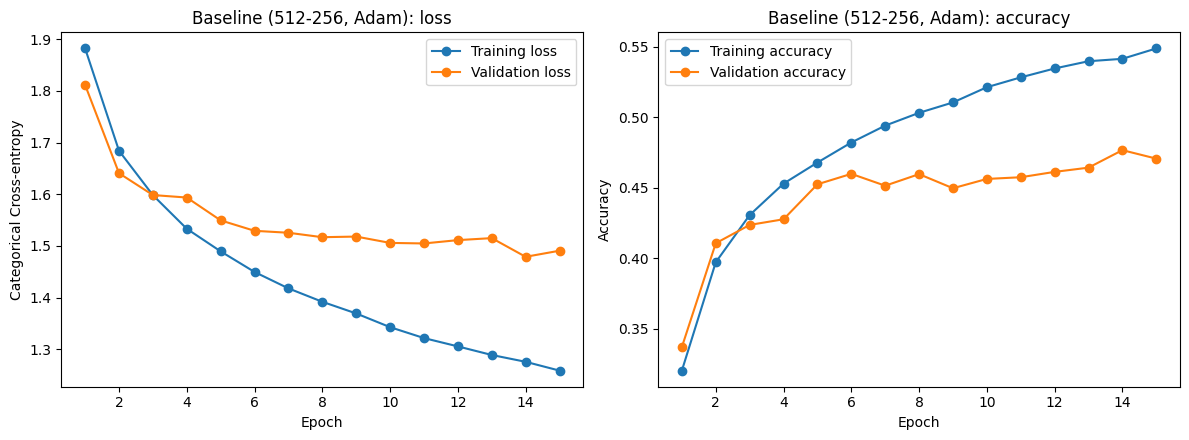

Final training accuracy: 0.549
Final validation accuracy: 0.471
Gap (train - validation): 0.078
Best validation accuracy: 0.477 (epoch 14 of 15)
Lowest validation loss: 1.479 (epoch 14 of 15)
Validation loss at the last epoch: 1.491


In [17]:
plot_history(baseline_history, "Baseline (512-256, Adam)")
summarize_history(baseline_history)

**Interpreting Baseline Curves**:
- **The network is learning.** Training accuracy rises steadily from about 33% after epoch 1 to about 54% after epoch 15, and training loss falls the whole time.
- **The curves separate after about epoch 3.** Up to then, validation accuracy tracks training accuracy. After that, training accuracy keeps climbing while validation accuracy grows more slowly, peaks at about 48% around epoch 11, and then hovers between 47% and 48%.
- **Overfitting begins around epoch 11.** Validation loss stops improving near epoch 7 (about 1.49), reaches its lowest value at epoch 11 (1.479), and then creeps *up* to 1.501 by epoch 15 while training loss keeps falling. From that point, further training makes the network better at the training images but not at new ones.
- Validation accuracy of about 48% is roughly **five times better than random guessing (10%)**, so the network has learned real structure. It also levels off at a fairly low value even before overfitting is severe, which suggests the limit comes mainly from the model design (flattened pixels fed to dense layers) and not just from training too long.

`Performance Metrics`

Now the baseline model is evaluated on the **10,000 test images**. Four metrics are reported:
- **Accuracy**: the share of all test images classified correctly.
- **Precision** (per class): of the images the model *labelled* as this class, the share that really belong to it. Low precision means many false alarms.
- **Recall** (per class): of the images that *truly belong* to this class, the share the model found. Low recall means many missed images.
- **F1-score**: the harmonic mean of precision and recall; it is low if either one is low.

The overall precision, recall, and F1 below are **weighted averages** across the 10 classes. Because every class has exactly 1,000 test images, the weighted and simple averages are identical here. The `classification_report` then lists each class separately, which shows where the model is strong and weak.

In [18]:
#Defome Performance Evaluation Function
def evaluate_on_test(model):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    accuracy = accuracy_score(y_test_int, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_int, y_pred, average="weighted", zero_division=0)
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f} (weighted)")
    print(f"Recall: {recall:.3f} (weighted)")
    print(f"F1-score: {f1:.3f} (weighted)")
    print("\nClassification report:")
    print(classification_report(y_test_int, y_pred, target_names=class_names, digits=3))

    metrics = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1}
    return y_pred, metrics

baseline_pred, baseline_metrics = evaluate_on_test(baseline_model)

Accuracy: 0.479
Precision: 0.487 (weighted)
Recall: 0.479 (weighted)
F1-score: 0.478 (weighted)

Classification report:
              precision    recall  f1-score   support

    airplane      0.630     0.407     0.495      1000
  automobile      0.541     0.629     0.582      1000
        bird      0.335     0.432     0.377      1000
         cat      0.344     0.292     0.316      1000
        deer      0.439     0.394     0.415      1000
         dog      0.351     0.348     0.350      1000
        frog      0.501     0.582     0.539      1000
       horse      0.575     0.510     0.541      1000
        ship      0.652     0.592     0.621      1000
       truck      0.498     0.603     0.546      1000

    accuracy                          0.479     10000
   macro avg      0.487     0.479     0.478     10000
weighted avg      0.487     0.479     0.478     10000



In [20]:
#Define Function to Identify highest & Lowest Classes by F1 Score
def print_class_extremes(y_true, y_pred, n=3):
    _, _, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    order = np.argsort(f1_per_class)
    print("Weakest classes (lowest F1):")
    for i in order[:n]:
        print(f"{class_names[i]:<11s} F1 = {f1_per_class[i]:.3f}")
    print("\nStrongest classes (highest F1):")
    for i in order[::-1][:n]:
        print(f"{class_names[i]:<11s} F1 = {f1_per_class[i]:.3f}")


print_class_extremes(y_test_int, baseline_pred)

Weakest classes (lowest F1):
cat         F1 = 0.316
dog         F1 = 0.350
bird        F1 = 0.377

Strongest classes (highest F1):
ship        F1 = 0.621
automobile  F1 = 0.582
truck       F1 = 0.546


**Interpreting Test Results**:
- **Test accuracy is about 48%** (weighted precision 0.487, recall 0.479, F1-score 0.478). This is very close to the final validation accuracy (47.1%), so the validation set gave a reliable preview and the model has not been tuned to it. The model beats chance (10%) by a wide margin but still misclassifies more than half of the test images.
- **Overall precision, recall and F1 are all close to accuracy** because the classes are perfectly balanced. The interesting differences are between classes.
- **Vehicles are easier than animals.** The best classes are ship (F1 0.62), automobile (0.58), airplane (0.49), and truck (0.55), alongside horse (0.54) and frog (0.54). The weakest are **bird (0.38), cat (0.32), deer (0.42), and dog (0.35)**.

`Confusion Matrix`

In [21]:
#Define Funtion for Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8.5, 7.5))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = cm.max() / 2
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > threshold else "black")
    #Write the count in each cell; white text on dark cells so it stays readable
    plt.tight_layout()
    plt.show()

In [22]:
#Define Function to Outline Most Frequent Mistakes
def print_top_confusions(y_true, y_pred, n=6):
    cm = confusion_matrix(y_true, y_pred)
    mistakes = cm.copy()
    np.fill_diagonal(mistakes, 0) #Ignore the correct predictions
    for flat_index in np.argsort(mistakes, axis=None)[::-1][:n]:
        true_class, wrong_class = np.unravel_index(flat_index, mistakes.shape)
        count = mistakes[true_class, wrong_class]
        share = count / cm[true_class].sum()
        print(f"{class_names[true_class]:<11s} predicted as {class_names[wrong_class]:<11s}"
              f"{count:4d} images ({share:.0%} of all {class_names[true_class]} images)")

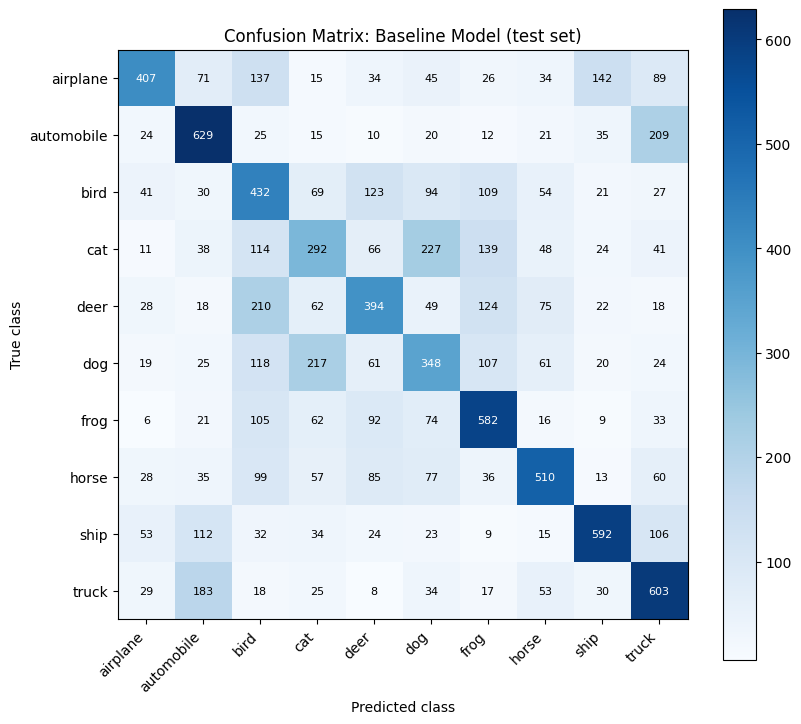

Most Frequent Mistakes:
cat         predicted as dog         227 images (23% of all cat images)
dog         predicted as cat         217 images (22% of all dog images)
deer        predicted as bird        210 images (21% of all deer images)
automobile  predicted as truck       209 images (21% of all automobile images)
truck       predicted as automobile  183 images (18% of all truck images)
airplane    predicted as ship        142 images (14% of all airplane images)


In [24]:
#Plot Confusion Matrix & Print Most Frequent Mistakes
plot_confusion_matrix(y_test_int, baseline_pred, "Confusion Matrix: Baseline Model (test set)")
print("Most Frequent Mistakes:")
print_top_confusions(y_test_int, baseline_pred)

**Confusion Matrix Insights**:
- The six most frequent mistakes are **cat labelled dog (227 images), dog labelled cat (217 images), deer labelled bird (210 images), automobile labelled truck (209 images), truck labelled automobile (183 images), and airplane labelled ship (142 images)**.
- **All six are between similar categories within the same family** (animals, vehicles), rather than between unrelated classes.
- This fits what the network can and cannot do. It has picked up coarse cues (overall colour, texture, and background) that separate broad groups, but it lacks the shape and part-level features (ears, snouts, wheels, cargo beds) needed to separate look-alike classes. The `Flatten` layer discards the spatial layout of the image, which is exactly the information that would help.
- The strong diagonal cells for ship, automobile, and airplane match the per-class scores above.

`Model Improvements`

**Experimentation Considerations:**

*   Does the **number of layers** matter? [1 hidden layer (512), 2 layers (512-256, the baseline), 3 layers (512-256-128)]

*   Does **layer size** matter? [1 hidden layer with 128 units versus 512 units]

*   Does the **optimizer** matter? [Adam (baseline) versus SGD with momentum versus RMSprop]

*   Does **data augmentation** help? [Baseline architecture trained on augmented images]


**To Note:** All variants are compared on the **validation** set, not the test set. The test set is reserved for the final model chosen at the end, so that the reported test score is not inflated by having been used to pick the winner

In [25]:
#Store every trained model and its history for comparison
BASELINE_NAME = "2 layers: 512-256 (baseline)"
experiments = {
    BASELINE_NAME: {"model": baseline_model, "history": baseline_history, "time": baseline_time}
}

#Define Experiment Function
def run_experiment(name, hidden_units, optimizer, augment=False):
    model = build_model(hidden_units)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    if augment:
        train_flow = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
        history = model.fit(train_flow, epochs=EPOCHS, validation_data=(x_val, y_val), verbose=0).history
    else:
        history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_val, y_val), verbose=0).history
    elapsed = time.time() - start
    experiments[name] = {"model": model, "history": history, "time": elapsed}
    print(f"{name:<38s} val acc {history['val_accuracy'][-1]:.3f}   "
          f"train acc {history['accuracy'][-1]:.3f} ({elapsed:.0f} s)")

**About the optimizers**:

**SGD** is classic gradient descent with one fixed learning rate; adding *momentum* (0.9) lets it build up speed along consistent directions and smooths out noisy updates.

**RMSprop** scales each weight's step size by a running average of its recent gradient magnitudes, so weights with large gradients take smaller steps. Adam combines both ideas.

In [26]:
#Number of layers and layer size (all with Adam)
run_experiment("1 layer: 128 units", [128], "adam")
run_experiment("1 layer: 512 units", [512], "adam")
run_experiment("3 layers: 512-256-128", [512, 256, 128], "adam")

1 layer: 128 units                     val acc 0.411   train acc 0.436 (111 s)
1 layer: 512 units                     val acc 0.466   train acc 0.505 (273 s)
3 layers: 512-256-128                  val acc 0.470   train acc 0.555 (303 s)


In [27]:
#Optimizers (baseline architecture)
run_experiment("512-256 with SGD (momentum)", [512, 256], keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))
run_experiment("512-256 with RMSprop", [512, 256], "rmsprop")

512-256 with SGD (momentum)            val acc 0.475   train acc 0.578 (230 s)
512-256 with RMSprop                   val acc 0.391   train acc 0.533 (270 s)


In [28]:
#Data augmentation (baseline architecture and optimizer)
run_experiment("512-256 with augmentation", [512, 256], "adam", augment=True)

512-256 with augmentation              val acc 0.474   train acc 0.462 (842 s)


`Experiment Comparison`

The table collects the key numbers for every model, sorted by final validation accuracy. The **train-validation gap** (training accuracy minus validation accuracy) is a direct measure of overfitting with a large gap meaning the model does much better on images it has trained on than on new ones.

In [30]:
rows = []
for name, result in experiments.items():
    h = result["history"]
    rows.append({
        "Experiment": name,
        "Parameters": result["model"].count_params(),
        "Final train acc": h["accuracy"][-1],
        "Final val acc": h["val_accuracy"][-1],
        "Train-val gap": h["accuracy"][-1] - h["val_accuracy"][-1],
        "Best val acc": max(h["val_accuracy"]),
        "Best epoch": int(np.argmax(h["val_accuracy"])) + 1,
        "Time (s)": result["time"],
    })

results_df = pd.DataFrame(rows).sort_values("Final val acc", ascending=False).reset_index(drop=True)
results_df.round(3)

,Experiment,Parameters,Final train acc,Final val acc,Train-val gap,Best val acc,Best epoch,Time (s)
0,512-256 with SGD (momentum),1707274,0.578,0.475,0.103,0.482,8,229.869
1,512-256 with augmentation,1707274,0.462,0.474,-0.012,0.489,13,841.956
2,2 layers: 512-256 (baseline),1707274,0.549,0.471,0.078,0.477,14,299.105
3,3 layers: 512-256-128,1738890,0.555,0.470,0.085,0.485,10,302.512
4,1 layer: 512 units,1578506,0.505,0.466,0.039,0.466,15,273.314
5,1 layer: 128 units,394634,0.436,0.411,0.025,0.413,13,111.024
6,512-256 with RMSprop,1707274,0.533,0.391,0.142,0.415,13,270.274


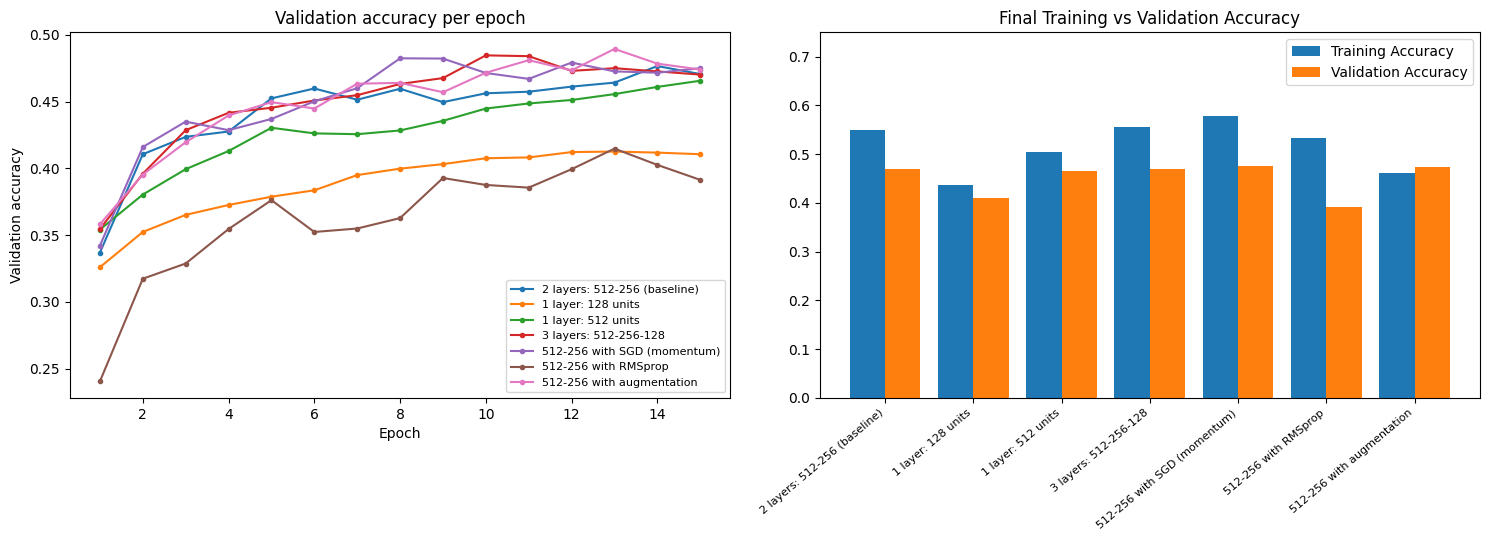

In [29]:
#Plot Validation Accuracy per Epoch for Each Model (Left) & Final Training/Validation Accuracy (Right)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for name, result in experiments.items():
    h = result["history"]
    axes[0].plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], marker=".", label=name)
axes[0].set_title("Validation accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation accuracy")
axes[0].legend(fontsize=8)
names = list(experiments.keys())
train_acc = [experiments[n]["history"]["accuracy"][-1] for n in names]
val_acc = [experiments[n]["history"]["val_accuracy"][-1] for n in names]
positions = np.arange(len(names))
axes[1].bar(positions - 0.2, train_acc, width=0.4, label="Training Accuracy")
axes[1].bar(positions + 0.2, val_acc, width=0.4, label="Validation Accuracy")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(names, rotation=40, ha="right", fontsize=8)
axes[1].set_ylim(0, 0.75)
axes[1].set_title("Final Training vs Validation Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

**What the experiments show**:

- **Layer size had the clearest effect** One hidden layer of 128 units reached 0.413 validation accuracy versus 0.466 for 512 units, a gain of about 5.5 points for four times as many parameters and about twice the training time. The 128-unit model also has almost no train-validation gap (0.025) and a low training accuracy (0.436): it is **underfitting**, meaning it is too small to fit even the training data well.
- **Overall picture** Once the first layer is large enough (about 512 units), the architecture and optimizer changes I tried move validation accuracy by only a few points, and the top three models are within one point of each other. Every variant plateaus at roughly 45-49%. That ceiling is set by the flatten-and-dense design and not by tuning, so more tweaking of this network type would give small returns.

`Data Augmentation Impact`

The cell below compares the baseline with the same architecture trained on augmented images. Everything else (architecture, optimizer, epochs, seed, validation data) is identical, so any difference is due to augmentation.

In [31]:
plain = experiments[BASELINE_NAME]["history"]
augmented = experiments["512-256 with augmentation"]["history"]

print(f"{'':<28s}{'Without aug':>12s}{'With aug':>12s}")
print(f"{'Final training accuracy':<28s}{plain['accuracy'][-1]:>12.3f}{augmented['accuracy'][-1]:>12.3f}")
print(f"{'Final validation accuracy':<28s}{plain['val_accuracy'][-1]:>12.3f}{augmented['val_accuracy'][-1]:>12.3f}")
print(f"{'Train-val gap':<28s}{plain['accuracy'][-1] - plain['val_accuracy'][-1]:>12.3f}"
      f"{augmented['accuracy'][-1] - augmented['val_accuracy'][-1]:>12.3f}")
print(f"{'Lowest validation loss':<28s}{min(plain['val_loss']):>12.3f}{min(augmented['val_loss']):>12.3f}")

change = augmented["val_accuracy"][-1] - plain["val_accuracy"][-1]
print(f"\nChange in final validation accuracy with augmentation: {change:+.3f}")

                             Without aug    With aug
Final training accuracy            0.549       0.462
Final validation accuracy          0.471       0.474
Train-val gap                      0.078      -0.012
Lowest validation loss             1.479       1.437

Change in final validation accuracy with augmentation: +0.003


**Effect of augmentation**:
- **Accuracy barely changed:** Validation accuracy went from 0.471 to 0.474 (+0.3 points), which is within noise. Augmentation did **not** clearly improve accuracy in these 15 epochs.
- **It did change how the model learns:** Training accuracy is *lower* (0.549 versus 0.462) because the training images are now altered and harder to classify, and the train-validation gap turned negative (-0.012). Validation accuracy being higher than training accuracy is expected here and is not a bug: training accuracy is measured on the augmented images, while validation images are unaltered.
- **Why the benefit is limited for this network type:** Augmentation teaches the model that a shifted, slightly rotated, or mirrored image is still the same class. A dense layer gives every pixel position its own weights, so it has no efficient way to reuse what it learned about an object in one position when the object appears in another. Convolutional networks share weights across positions and normally benefit far more from augmentation.
- **Cost:** Training took about four times longer than the other runs on my machine, because each augmented batch is generated on the fly on the CPU.

`Final Model & Test-set Evaluation`

The model with the highest final validation accuracy is selected and evaluated **once** on the untouched test set, then compared with the baseline's test results from earlier. Choosing on validation accuracy and reporting on test accuracy keeps the final number honest.

In [32]:
best_name = results_df.loc[0, "Experiment"]
best_model = experiments[best_name]["model"]
print("Selected model (highest final validation accuracy):", best_name)
print()

best_pred, best_metrics = evaluate_on_test(best_model)

Selected model (highest final validation accuracy): 512-256 with SGD (momentum)

Accuracy: 0.489
Precision: 0.505 (weighted)
Recall: 0.489 (weighted)
F1-score: 0.486 (weighted)

Classification report:
              precision    recall  f1-score   support

    airplane      0.667     0.440     0.530      1000
  automobile      0.528     0.699     0.602      1000
        bird      0.396     0.377     0.386      1000
         cat      0.319     0.442     0.371      1000
        deer      0.544     0.243     0.336      1000
         dog      0.389     0.371     0.380      1000
        frog      0.504     0.582     0.540      1000
       horse      0.554     0.559     0.556      1000
        ship      0.668     0.573     0.617      1000
       truck      0.483     0.608     0.539      1000

    accuracy                          0.489     10000
   macro avg      0.505     0.489     0.486     10000
weighted avg      0.505     0.489     0.486     10000



In [33]:
#Baseline versus selected model on the test set
comparison = pd.DataFrame({"Baseline": baseline_metrics, "Selected model": best_metrics})
print(comparison.round(3))

print("\n")
print_class_extremes(y_test_int, best_pred)

           Baseline  Selected model
Accuracy      0.479           0.489
Precision     0.487           0.505
Recall        0.479           0.489
F1-score      0.478           0.486


Weakest classes (lowest F1):
deer        F1 = 0.336
cat         F1 = 0.371
dog         F1 = 0.380

Strongest classes (highest F1):
ship        F1 = 0.617
automobile  F1 = 0.602
horse       F1 = 0.556


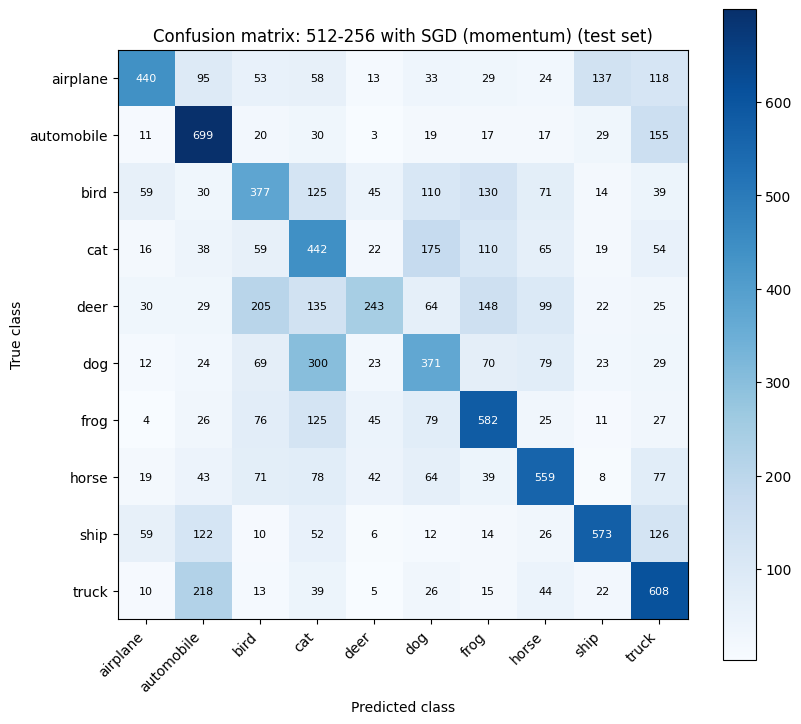

Most frequent mistakes:
dog         predicted as cat         300 images (30% of all dog images)
truck       predicted as automobile  218 images (22% of all truck images)
deer        predicted as bird        205 images (20% of all deer images)
cat         predicted as dog         175 images (18% of all cat images)
automobile  predicted as truck       155 images (16% of all automobile images)
deer        predicted as frog        148 images (15% of all deer images)


In [36]:
#Plot Confusion Matrix (Selected Model)
plot_confusion_matrix(y_test_int, best_pred, f"Confusion matrix: {best_name} (test set)")
print("Most frequent mistakes:")
print_top_confusions(y_test_int, best_pred)

**Final model**: the highest validation accuracy belonged to the **SGD with momentum** model (0.475), so it was the one evaluated on the test set.

- **Test accuracy is 0.489 versus 0.479 for the baseline**, and weighted F1 is 0.486 versus 0.478. A difference of 0.8 is far greater than the roughly 0.5-point uncertainty of a 10,000-image test set, so the tuned model is performing **moderately better** than the Adam baseline on new images.
- **The per-class pattern is unchanged:** Ship (F1 0.62), automobile (0.60), and horse (0.56) are the best classes; deer (0.34), cat (0.37), and dog (0.38) are the weakest.
- **The most frequent mistakes are again between similar categories**: dog labelled cat (300 images), truck labelled automobile (218), deer labelled bird (205 images), cat labelled dog (175 images), automobile labelled truck (155 images), & deer labelled frog (148).
- **Takeaway:** For this kind of network, tuning layers, sizes, and optimizers gained at most about one point. The bigger lever is changing the type of model, which is discussed next.

**Task 5: Conclusion & Future Outlook**

`Analysis Summary`

**Summary**

- CIFAR-10 was loaded through Keras (50,000 training and 10,000 test images), normalized to 0-1, and the labels were one-hot encoded. A stratified 45,000 / 5,000 split created the training and validation sets, and the test set was left untouched until evaluation.
- The baseline was a feedforward network (Flatten, Dense 512 ReLU, Dense 256 ReLU, Dense 10 softmax; 1,707,274 parameters) compiled with Adam and categorical cross-entropy and trained for 15 epochs with batch size 64. It reached about **48.6% test accuracy** (weighted F1 0.479), roughly five times better than random guessing, but overfitting also occured.
- Experiments varied layer count, layer size, optimizer, and augmentation. **Layer size** had the clearest effect (128 to 512 units), a third hidden layer did not help, SGD with momentum and Adam performed about the same, RMSprop was worse, and augmentation reduced the train-validation gap but did not clearly raise accuracy in 15 epochs while making training about four times slower.
- The model selected on validation data scored **48.9%** on the test set, statistically indistinguishable from the baseline.
- The model does best on vehicles and worst on animals, and its most frequent mistakes are between look-alike classes (cat/dog, automobile/truck, deer/horse).

**Why accuracy stalls near 50%**

A plain feedforward network is a limited tool for images. `Flatten` throws away the 2-D layout, so the network has no idea that neighbouring pixels form edges and shapes. Every pixel position has its own weights, which means a cat's ear must be learned separately at every location, and the parameter count grows quickly with image size (92% of the baseline's parameters sit in the first layer). The network can learn colour and texture statistics, which is enough to separate a ship from a horse, but not the shape details that separate a cat from a dog.

This should not be read as "deep learning is weak". It shows the limit of the *simplest* neural architecture. Traditional models such as Random Forests or SVMs trained on raw pixels face a similar limitation.

`Potential Improvements`

**Potential improvements and future work**

1. **Convolutional neural networks (CNNs).** Convolutional layers look at small local patches and reuse the same filters across the whole image, and pooling layers add tolerance to small shifts. This directly addresses the weaknesses above, and small CNNs are commonly reported to reach roughly 70-80% or more on CIFAR-10.
2. **Regularization.** Dropout, L2 weight penalties, and batch normalization would shrink the train-validation gap that grew with larger and deeper networks.
4. **Longer training with a learning-rate schedule.** The SGD and augmented models were still improving at epoch 15, so they may benefit from more epochs.
5. **Systematic tuning and repeated runs.** Learning rates (especially for RMSprop and SGD) were left at defaults. A structured search, with several random seeds per setting to measure run-to-run variation, would make small differences between models more trustworthy.
7. **Transfer learning.** Starting from a network pretrained on a large image dataset and fine-tuning it on CIFAR-10 typically gives far higher accuracy than training from scratch.